# 02 - Escalamiento lineal

Escala registros semilla contra el espectro objetivo EPU_475 usando el promedio logaritmico de ordenadas en el rango de interes.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from signalprocessor.io import read_motion, read_target_spectrum
from signalprocessor.scaling import linear_scale


In [2]:
target = read_target_spectrum(ROOT / 'examples/data/response_spectrum/EPU_475.csv')
motion_paths = sorted((ROOT / 'examples/data/motion').glob('*.csv'))
results = [linear_scale(read_motion(path), target, t_min=0.2, t_max=2.0) for path in motion_paths]

summary = pd.DataFrame([
    {
        'record': path.stem,
        'factor': result.factor,
        'max_abs_error': result.max_abs_error,
        'rms_log_error': result.rms_log_error,
    }
    for path, result in zip(motion_paths, results)
]).sort_values('rms_log_error')
summary


,record,factor,max_abs_error,rms_log_error
4,TARAPACAEW,1.997653,0.375883,0.228977
5,TARAPACANS,1.948510,0.623975,0.266764
3,LIMANS,1.061648,0.791750,0.314208
2,LIMAEW,0.975773,1.321125,0.407317
1,ATICONS,0.601198,0.865293,0.488787
0,ATICOEW,0.653853,1.498769,0.517697


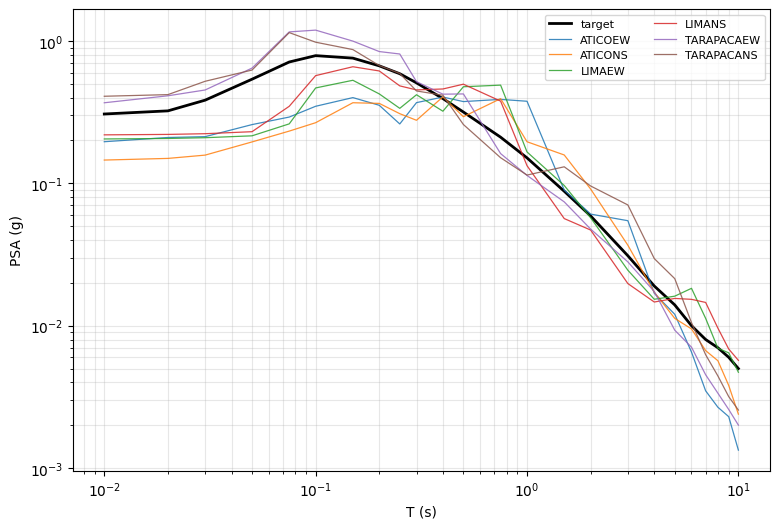

In [3]:
plt.figure(figsize=(9, 6))
plt.loglog(target.periods, target.sa, 'k-', lw=2.0, label='target')
for path, result in zip(motion_paths, results):
    plt.loglog(result.scaled_spectrum.periods, result.scaled_spectrum.sa, lw=0.9, alpha=0.85, label=path.stem)
plt.xlabel('T (s)')
plt.ylabel('PSA (g)')
plt.grid(True, which='both', alpha=0.3)
plt.legend(ncol=2, fontsize=8);
